# Spot detection in fluorescence images

This notebook provides a demo for the fluorescent spot detection library.

- **Channel 1**: DAPI (nuclear stain)
- **Channel 2**: GFP (protein of interest)

In [1]:
from pathlib import Path
from spot_detect.io import load_image
from spot_detect.detection import remove_bg, smooth_image, detect_spots, calculate_channel_statistics, calculate_overlap
from spot_detect.plots import plot_channel, plot_overlay
from skimage.measure import label
import json

## Directories

In [2]:
# Set project root directory
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
# Load directories from config file
config_path = (project_root / "config.json").resolve()
with open(config_path, "r") as f:
        config = json.load(f)
input_dir = Path(project_root / "data" / "raw_images").resolve()

In [3]:
# Load input image
img_name = "sample_image.tif"
print(f"Loading image: {img_name} from {input_dir}")
img = load_image((input_dir / img_name).resolve())

Loading image: sample_image.tif from C:\Users\valer\Desktop\spot_detect\data\raw_images


## Process first channel (DAPI)
Background substraction, smoothing and threshold based spot detection. 
Visualize raw channel, smoothed image and detected spots.
NOTE: default parameters such as method for background subtraction and thesholds can be taken from the config file. 

{'channel': 'DAPI', 'mean': np.float64(328.11), 'std': np.float64(285.35), 'min': np.float64(-654.13), 'max': np.float64(3505.01)}
Found 9 spots in DAPI channel


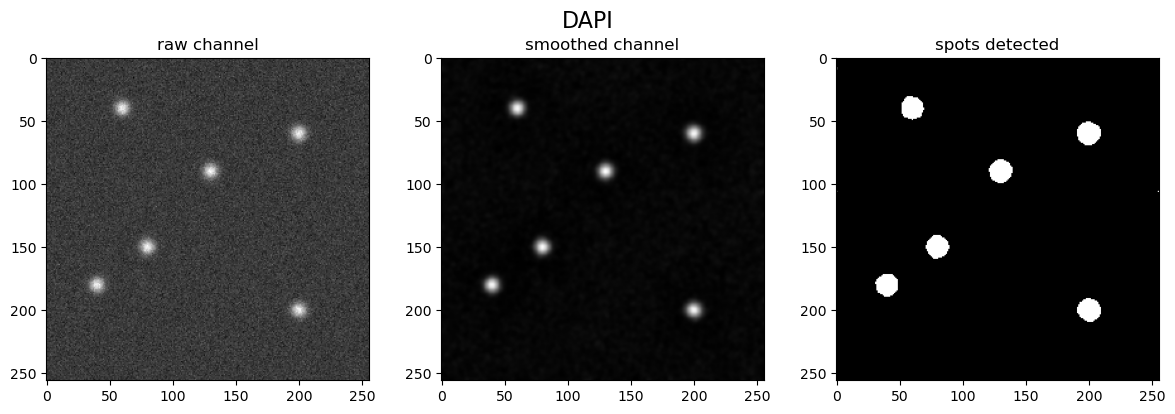

In [ ]:
# Inspect channel information
ch_name = "DAPI"
stats = calculate_channel_statistics(img[0], ch_name)
print(stats)

# Configure parameters for background subtraction
bg_method = "gaussian"
bg_sigma = 20
smooth_method = "gaussian"
smooth_sigma = 1.5
det_method = "manual"
manual_threshold = 300

# Remove background, smooth and detect spots
img_no_bg = remove_bg(img[0], bg_method, bg_sigma)
img_smoothed = smooth_image(img_no_bg, smooth_method, smooth_sigma)
n_spots_dapi, mask_dapi = detect_spots(img_smoothed, det_method, manual_threshold, otsu_nbins=None)

# Report results of spot detection and visualize
print(f"Found {n_spots_dapi} spots in {ch_name} channel")
plot_channel(img[0], img_smoothed, mask_dapi, ch_name);

## Process second channel (GFP)
Background substraction, smoothing and threshold based spot detection. 
Visualize raw channel, smoothed image and detected spots.
NOTE: default parameters such as method for background subtraction and thesholds can be taken from the config file. 

{'channel': 'GFP', 'mean': np.float64(516.71), 'std': np.float64(326.85), 'min': np.float64(-989.47), 'max': np.float64(3016.79)}
38.19028210134766 1494.6476675892886
126.55443574554735
Found 260 spots in GFP channel


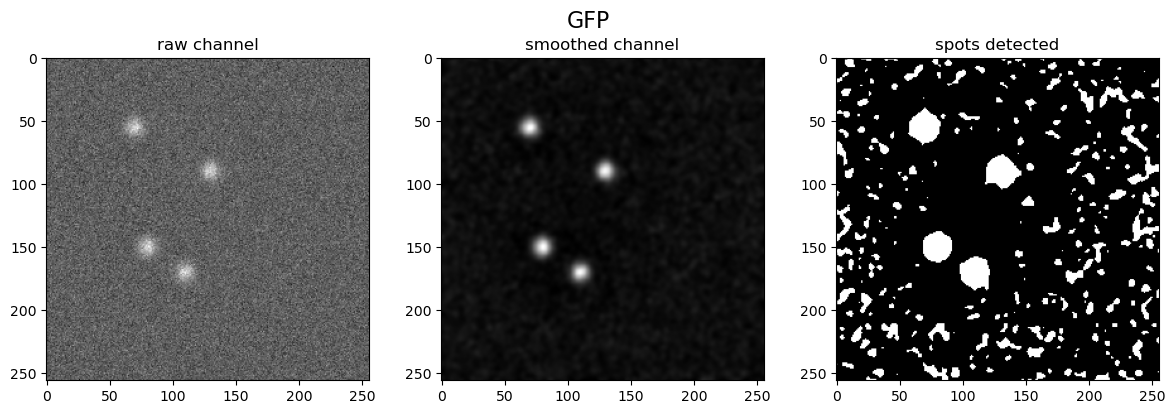

In [ ]:
# Inspect channel information
ch_name = "GFP"
stats = calculate_channel_statistics(img[1], ch_name)
print("Raw image statistics\n", stats)

# Configure parameters for background subtraction
bg_method = "gaussian"
bg_sigma = 25
smooth_method = "gaussian"
smooth_sigma = 2.0
det_method = "manual"
manual_threshold = 350

# Remove background, smooth and detect spots

img_no_bg = remove_bg(img[1], bg_method, bg_sigma)
img_smoothed = smooth_image(img_no_bg, smooth_method, smooth_sigma)
n_spots_gfp, mask_gfp = detect_spots(img_smoothed, det_method, manual_threshold, otsu_nbins=None)
stats = calculate_channel_statistics(img_smoothed, ch_name)
print("Cleaned image statistics\n", stats)

# Report results of spot detection and visualize
print(f"Found {n_spots_gfp} spots in {ch_name} channel")
plot_channel(img[1], img_smoothed, mask_gfp, ch_name);

## Calculate and display overlay between channels
Calculate the overlap between the two spot masks and report % of overlapping pixels.
Visualize overlay.

Overlap pixels: 645  (6.9% of union)


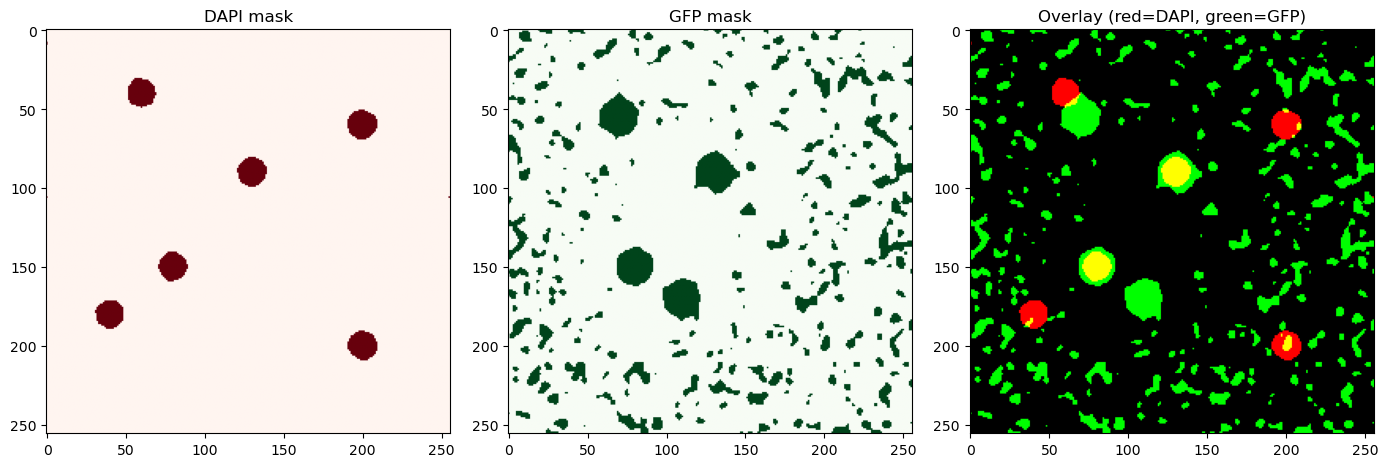

In [6]:
# Find overlapping pixels detected as spots and report result
n_overlap, overlap_pct = calculate_overlap(mask_dapi, mask_gfp)
print(f"Overlap pixels: {n_overlap}  ({overlap_pct:.1f}% of union)")
    
# Visualize overlay of detected spots in the two channels
plot_overlay(mask_dapi, mask_gfp, plot=True);